In [1]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv('placement.csv')

In [4]:
df


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [5]:
df.shape


(100, 4)

In [6]:
df = df.iloc[:,1:]

In [11]:
df.head()


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [12]:
import matplotlib.pyplot as plt 

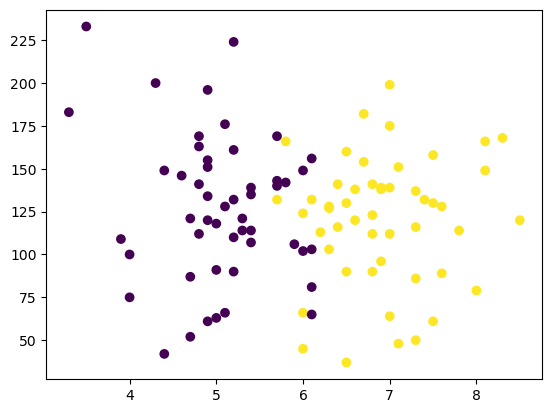

In [17]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [18]:
x = df.iloc[:,0:2]

In [19]:
x.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [30]:
y = df.iloc[:,-1]

In [31]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [32]:
y.shape

(100,)

for splitting the training set and test set 

In [33]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1)

In [36]:
x_train.head()

,cgpa,iq
16,5.2,224.0
52,7.0,175.0
2,5.3,121.0
27,6.0,124.0
32,7.0,139.0


In [38]:
from sklearn.preprocessing import StandardScaler


In [39]:
scaler =  StandardScaler()

In [40]:
x_train = scaler.fit_transform(x_train)

In [42]:
x_train

array([[-0.73231153,  2.41925034],
       [ 0.87520158,  1.21779831],
       [-0.64300524, -0.10625086],
       [-0.01786126, -0.03269257],
       [ 0.87520158,  0.33509886],
       [-0.19647382,  0.99712345],
       [ 0.07144503, -0.54760058],
       [-1.4467618 ,  0.58029316],
       [ 1.14312043, -0.96443088],
       [-1.08953666,  0.92356516],
       [-0.9109241 , -0.84183373],
       [ 1.321733  , -1.57741661],
       [ 1.85757071,  0.99712345],
       [-0.28578011,  1.07068174],
       [-2.25051836,  2.6399252 ],
       [ 0.07144503, -1.47933889],
       [ 0.96450787, -1.89616919],
       [ 0.16075131, -0.30240629],
       [ 0.87520158, -1.50385832],
       [ 0.07144503,  0.16346286],
       [ 0.7858953 , -0.71923659],
       [-0.73231153, -0.37596458],
       [ 1.23242672,  0.16346286],
       [ 0.2500576 , -0.54760058],
       [-1.53606808,  1.83078404],
       [-0.19647382,  0.40865715],
       [ 0.7858953 ,  0.33509886],
       [ 1.321733  ,  0.114424  ],
       [-0.01786126,

In [53]:
x_test = scaler.fit_transform(x_test)

In [56]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [57]:
#model training
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
y_pred = clf.predict(x_test)

In [59]:
y_test

0     1
22    0
13    1
94    0
69    1
57    1
24    0
81    0
41    0
68    0
Name: placement, dtype: int64

In [61]:
from sklearn.metrics import accuracy_score

In [63]:
accuracy_score(y_test,y_pred )

1.0

In [65]:
y_pred

array([1, 0, 1, 0, 1, 1, 0, 0, 0, 0])

In [70]:
!pip install mlxtend --no-deps

  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)


In [71]:
 from mlxtend.plotting import plot_decision_regions

<Axes: >

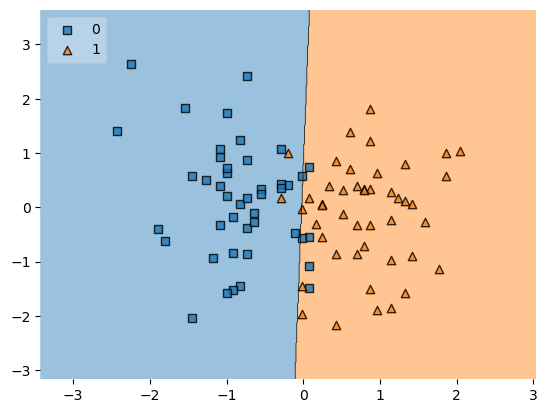

In [74]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [75]:
import pickle

In [77]:
pickle.dump(clf,open('placement_model.pkl','wb'))